In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Permanent project storage on your Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/HAR_1D_CNN_Project")
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
TABLES_DIR = PROJECT_DIR / "results" / "tables"

for folder in [DATA_DIR, CHECKPOINT_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Created/verified folders:")
for folder in [DATA_DIR, CHECKPOINT_DIR, FIGURES_DIR, TABLES_DIR]:
    print(" -", folder)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/HAR_1D_CNN_Project
Created/verified folders:
 - /content/drive/MyDrive/HAR_1D_CNN_Project/data
 - /content/drive/MyDrive/HAR_1D_CNN_Project/checkpoints
 - /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures
 - /content/drive/MyDrive/HAR_1D_CNN_Project/results/tables


In [ ]:
DATASET_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00240/UCI%20HAR%20Dataset.zip"
)

zip_path = DATA_DIR / "UCI_HAR_Dataset.zip"
dataset_path = DATA_DIR / "UCI HAR Dataset"

if not zip_path.exists():
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(DATASET_URL, zip_path)
    print("Download complete.")
else:
    print("ZIP already exists — skipping download.")

if not dataset_path.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Dataset is already extracted — skipping extraction.")

print("\nDataset path:", dataset_path)
print("Top-level contents:")
print(sorted(os.listdir(dataset_path)))

Download complete.
Extracting dataset...
Extraction complete.

Dataset path: /content/drive/MyDrive/HAR_1D_CNN_Project/data/UCI HAR Dataset
Top-level contents:
['.DS_Store', 'README.txt', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


In [ ]:
ACTIVITY_NAMES = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying",
}

RAW_SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

def load_raw_signals(split):
    """
    Output shape: (number_of_windows, 128_timesteps, 9_channels)
    """
    inertial_dir = dataset_path / split / "Inertial Signals"
    signals = []

    for signal_name in RAW_SIGNAL_NAMES:
        file_path = inertial_dir / f"{signal_name}_{split}.txt"
        signals.append(np.loadtxt(file_path))

    return np.stack(signals, axis=-1)

def load_labels(split):
    return np.loadtxt(dataset_path / split / f"y_{split}.txt", dtype=int)

def load_subjects(split):
    return np.loadtxt(dataset_path / split / f"subject_{split}.txt", dtype=int)

X_train_raw = load_raw_signals("train")
X_test_raw = load_raw_signals("test")

y_train = load_labels("train")
y_test = load_labels("test")

subjects_train = load_subjects("train")
subjects_test = load_subjects("test")

print("Raw train signals:", X_train_raw.shape)
print("Raw test signals: ", X_test_raw.shape)
print("Train labels:      ", y_train.shape)
print("Test labels:       ", y_test.shape)
print("Train subjects:    ", np.unique(subjects_train))
print("Test subjects:     ", np.unique(subjects_test))

Raw train signals: (7352, 128, 9)
Raw test signals:  (2947, 128, 9)
Train labels:       (7352,)
Test labels:        (2947,)
Train subjects:     [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Test subjects:      [ 2  4  9 10 12 13 18 20 24]


In [ ]:
# These are the dataset's precomputed time/frequency-domain features.
# We use them only later for the Random Forest baseline.

X_train_features = pd.read_csv(
    dataset_path / "train" / "X_train.txt",
    sep=r"\s+",
    header=None
)

X_test_features = pd.read_csv(
    dataset_path / "test" / "X_test.txt",
    sep=r"\s+",
    header=None
)

feature_names = pd.read_csv(
    dataset_path / "features.txt",
    sep=r"\s+",
    header=None,
    names=["feature_id", "feature_name"]
)

print("Engineered train features:", X_train_features.shape)
print("Engineered test features: ", X_test_features.shape)

print("\nFirst 10 engineered feature names:")
display(feature_names.head(10))

Engineered train features: (7352, 561)
Engineered test features:  (2947, 561)

First 10 engineered feature names:


,feature_id,feature_name
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y
5,6,tBodyAcc-std()-Z
6,7,tBodyAcc-mad()-X
7,8,tBodyAcc-mad()-Y
8,9,tBodyAcc-mad()-Z
9,10,tBodyAcc-max()-X


In [ ]:
assert X_train_raw.shape == (7352, 128, 9)
assert X_test_raw.shape == (2947, 128, 9)

assert X_train_features.shape == (7352, 561)
assert X_test_features.shape == (2947, 561)

assert not np.isnan(X_train_raw).any()
assert not np.isnan(X_test_raw).any()

assert not X_train_features.isna().any().any()
assert not X_test_features.isna().any().any()

assert set(np.unique(y_train)) == set(ACTIVITY_NAMES.keys())
assert set(np.unique(y_test)) == set(ACTIVITY_NAMES.keys())

# No person appears in both official train and test partitions.
assert set(np.unique(subjects_train)).isdisjoint(set(np.unique(subjects_test)))

print("All integrity checks passed.")

All integrity checks passed.


,Train,Test
Walking,1226,496
Walking Upstairs,1073,471
Walking Downstairs,986,420
Sitting,1286,491
Standing,1374,532
Laying,1407,537


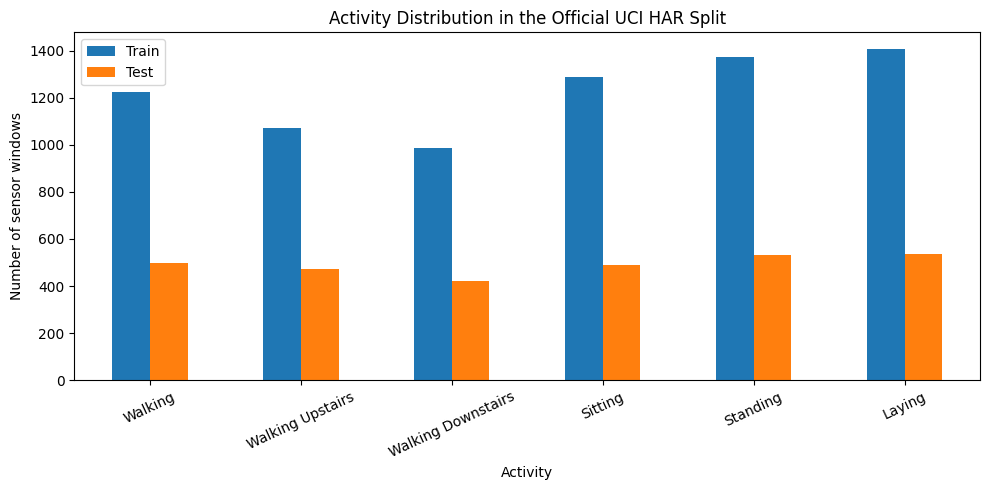

Saved: /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/class_distribution.png


In [ ]:
activity_order = list(ACTIVITY_NAMES.values())

train_counts = (
    pd.Series(y_train)
    .map(ACTIVITY_NAMES)
    .value_counts()
    .reindex(activity_order)
)

test_counts = (
    pd.Series(y_test)
    .map(ACTIVITY_NAMES)
    .value_counts()
    .reindex(activity_order)
)

class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

display(class_distribution)

ax = class_distribution.plot(
    kind="bar",
    figsize=(10, 5),
    rot=25,
    title="Activity Distribution in the Official UCI HAR Split"
)

ax.set_xlabel("Activity")
ax.set_ylabel("Number of sensor windows")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", FIGURES_DIR / "class_distribution.png")

### Observation — class distribution
The six activities are represented in both the training and test partitions, with no severely underrepresented class. The official split is subject-separated, so the model will be evaluated on people not seen during training rather than on random windows from the same participants.



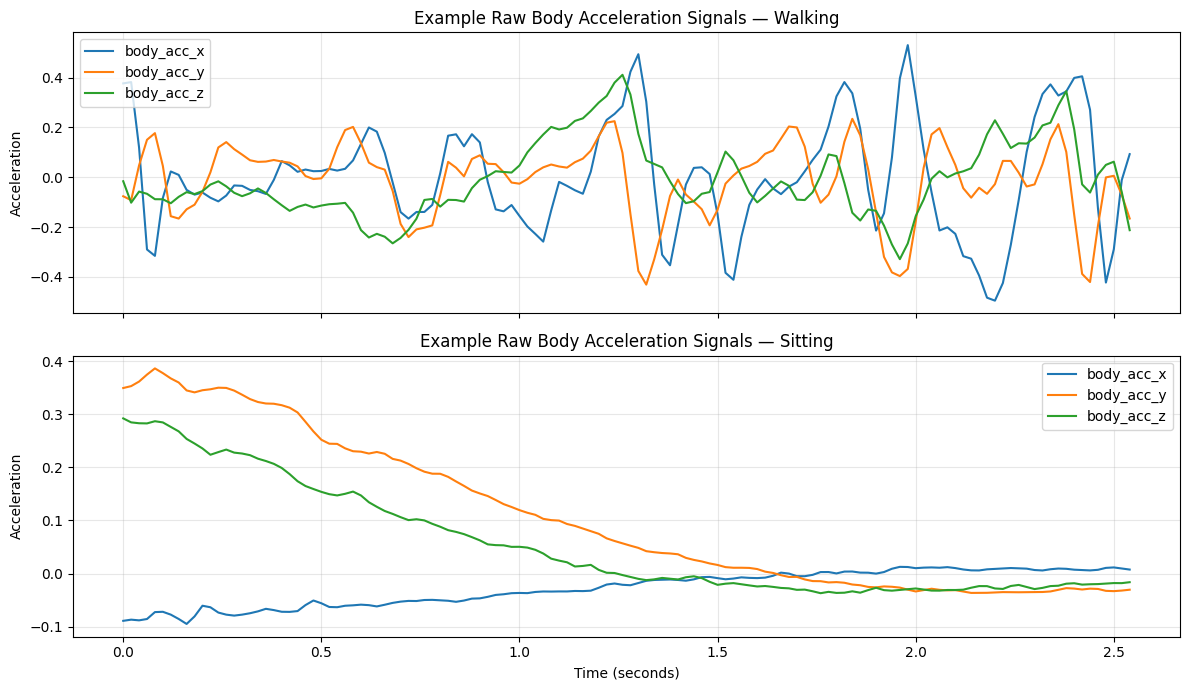

Saved: /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/walking_vs_sitting_signals.png


In [ ]:
# Find one training example of Walking and one of Sitting.
walking_index = np.where(y_train == 1)[0][0]
sitting_index = np.where(y_train == 4)[0][0]

time_seconds = np.arange(128) / 50  # Dataset sampling frequency is 50 Hz.

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for channel_idx, channel_name in enumerate(RAW_SIGNAL_NAMES[:3]):
    axes[0].plot(
        time_seconds,
        X_train_raw[walking_index, :, channel_idx],
        label=channel_name
    )

axes[0].set_title("Example Raw Body Acceleration Signals — Walking")
axes[0].set_ylabel("Acceleration")
axes[0].legend()
axes[0].grid(alpha=0.3)

for channel_idx, channel_name in enumerate(RAW_SIGNAL_NAMES[:3]):
    axes[1].plot(
        time_seconds,
        X_train_raw[sitting_index, :, channel_idx],
        label=channel_name
    )

axes[1].set_title("Example Raw Body Acceleration Signals — Sitting")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Acceleration")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "walking_vs_sitting_signals.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", FIGURES_DIR / "walking_vs_sitting_signals.png")

### Observation — raw motion patterns
The walking window shows stronger and more periodic acceleration variation than the sitting window, which is comparatively stable. This supports using a 1D CNN: the model can learn local temporal motion patterns directly from the raw multichannel signals instead of relying only on manually engineered summary features.

In [ ]:
processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(exist_ok=True)

np.save(processed_dir / "X_train_raw.npy", X_train_raw.astype(np.float32))
np.save(processed_dir / "X_test_raw.npy", X_test_raw.astype(np.float32))

np.save(processed_dir / "y_train.npy", y_train.astype(np.int64))
np.save(processed_dir / "y_test.npy", y_test.astype(np.int64))

np.save(processed_dir / "subjects_train.npy", subjects_train.astype(np.int64))
np.save(processed_dir / "subjects_test.npy", subjects_test.astype(np.int64))

X_train_features.to_csv(processed_dir / "X_train_features.csv", index=False)
X_test_features.to_csv(processed_dir / "X_test_features.csv", index=False)

print("Saved processed data to:", processed_dir)
print("\nFiles:")
for path in sorted(processed_dir.iterdir()):
    print("-", path.name)

Saved processed data to: /content/drive/MyDrive/HAR_1D_CNN_Project/data/processed

Files:
- X_test_features.csv
- X_test_raw.npy
- X_train_features.csv
- X_train_raw.npy
- subjects_test.npy
- subjects_train.npy
- y_test.npy
- y_train.npy


In [9]:
# -------------------------------------------------------
# Subject-aware train / validation split
# -------------------------------------------------------

# These subjects are originally in the official training partition.
# We hold them out entirely for validation.
VAL_SUBJECTS = np.array([27, 28, 29, 30])

train_mask = ~np.isin(subjects_train, VAL_SUBJECTS)
val_mask = np.isin(subjects_train, VAL_SUBJECTS)

X_train_cnn = X_train_raw[train_mask]
y_train_cnn = y_train[train_mask]

X_val_cnn = X_train_raw[val_mask]
y_val_cnn = y_train[val_mask]

subjects_train_cnn = subjects_train[train_mask]
subjects_val_cnn = subjects_train[val_mask]

print("Training subjects:", sorted(np.unique(subjects_train_cnn)))
print("Validation subjects:", sorted(np.unique(subjects_val_cnn)))

print("\nCNN train shape:", X_train_cnn.shape)
print("CNN val shape:  ", X_val_cnn.shape)
print("CNN test shape: ", X_test_raw.shape)

assert set(np.unique(subjects_train_cnn)).isdisjoint(set(np.unique(subjects_val_cnn)))
assert set(np.unique(subjects_val_cnn)).isdisjoint(set(np.unique(subjects_test)))

print("\nNo subject leakage: PASSED")

Training subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26)]
Validation subjects: [np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

CNN train shape: (5867, 128, 9)
CNN val shape:   (1485, 128, 9)
CNN test shape:  (2947, 128, 9)

No subject leakage: PASSED


In [10]:
# -------------------------------------------------------
# Verify every activity is represented in train and validation
# -------------------------------------------------------

train_activity_counts = (
    pd.Series(y_train_cnn)
    .map(ACTIVITY_NAMES)
    .value_counts()
    .reindex(activity_order)
)

val_activity_counts = (
    pd.Series(y_val_cnn)
    .map(ACTIVITY_NAMES)
    .value_counts()
    .reindex(activity_order)
)

split_distribution = pd.DataFrame({
    "CNN Train": train_activity_counts,
    "Validation": val_activity_counts
})

display(split_distribution)

assert (split_distribution["CNN Train"] > 0).all()
assert (split_distribution["Validation"] > 0).all()

print("Every activity appears in both training and validation: PASSED")

,CNN Train,Validation
Walking,997,229
Walking Upstairs,857,216
Walking Downstairs,786,200
Sitting,1022,264
Standing,1091,283
Laying,1114,293


Every activity appears in both training and validation: PASSED


In [11]:
# -------------------------------------------------------
# Channel-wise normalization using TRAINING data only
# -------------------------------------------------------

# Mean and standard deviation for each of the 9 channels.
# Shape: (1, 1, 9), so NumPy applies them across every window and timestep.
channel_mean = X_train_cnn.mean(axis=(0, 1), keepdims=True)
channel_std = X_train_cnn.std(axis=(0, 1), keepdims=True)

# Prevent division by zero in the unlikely case of a constant channel.
channel_std = np.where(channel_std < 1e-8, 1.0, channel_std)

X_train_cnn_norm = ((X_train_cnn - channel_mean) / channel_std).astype(np.float32)
X_val_cnn_norm = ((X_val_cnn - channel_mean) / channel_std).astype(np.float32)
X_test_cnn_norm = ((X_test_raw - channel_mean) / channel_std).astype(np.float32)

print("Normalized train mean:", round(float(X_train_cnn_norm.mean()), 5))
print("Normalized train std: ", round(float(X_train_cnn_norm.std()), 5))

print("\nNormalized shapes:")
print("Train:", X_train_cnn_norm.shape)
print("Val:  ", X_val_cnn_norm.shape)
print("Test: ", X_test_cnn_norm.shape)

Normalized train mean: 0.0
Normalized train std:  1.0

Normalized shapes:
Train: (5867, 128, 9)
Val:   (1485, 128, 9)
Test:  (2947, 128, 9)


In [12]:
# -------------------------------------------------------
# Save CNN-ready arrays to Google Drive
# -------------------------------------------------------

np.save(processed_dir / "X_train_cnn.npy", X_train_cnn_norm)
np.save(processed_dir / "X_val_cnn.npy", X_val_cnn_norm)
np.save(processed_dir / "X_test_cnn.npy", X_test_cnn_norm)

np.save(processed_dir / "y_train_cnn.npy", y_train_cnn.astype(np.int64))
np.save(processed_dir / "y_val_cnn.npy", y_val_cnn.astype(np.int64))
np.save(processed_dir / "y_test_cnn.npy", y_test.astype(np.int64))

np.save(processed_dir / "channel_mean.npy", channel_mean.astype(np.float32))
np.save(processed_dir / "channel_std.npy", channel_std.astype(np.float32))

print("CNN-ready data saved successfully.\n")

for path in sorted(processed_dir.iterdir()):
    print("-", path.name)

CNN-ready data saved successfully.

- X_test_cnn.npy
- X_test_features.csv
- X_test_raw.npy
- X_train_cnn.npy
- X_train_features.csv
- X_train_raw.npy
- X_val_cnn.npy
- channel_mean.npy
- channel_std.npy
- subjects_test.npy
- subjects_train.npy
- y_test.npy
- y_test_cnn.npy
- y_train.npy
- y_train_cnn.npy
- y_val_cnn.npy


## Data preparation summary

The project uses the official UCI HAR subject-separated test split. A separate validation set was created by holding out four participants from the original training partition. This prevents the same participant from appearing in both model training and validation.

Raw signals were normalized channel-wise using only the training partition statistics. The final CNN input consists of 128-timestep windows with 9 sensor channels, while the Random Forest baseline will use the dataset’s 561 handcrafted features.